In [8]:
import pandas as pd
import matplotlib.pyplot as plt

df_log = pd.read_csv("dataset/product_log.csv")
df_log["Num"] = df_log["Num"].interpolate()

df_master = pd.read_csv("dataset/product_master.csv")

df_sale = pd.merge(df_log, df_master, on="Product")

df_sale["Sale"] = df_sale["Price"] * df_sale["Num"]

df_sale["Date"] = pd.to_datetime(df_sale["Date"])
df_sale = df_sale.set_index("Date")

df_sale["Month"] = df_sale.index.month

df_sale_pivot = df_sale.pivot_table(
    values="Sale",
    index="Month",
    columns="Product",
    aggfunc="sum"
)

df_sale_pivot

Product,A,B
Month,,
1,8000.0,20400.0
2,32500.0,20400.0
3,40000.0,34800.0


<Axes: xlabel='Month'>

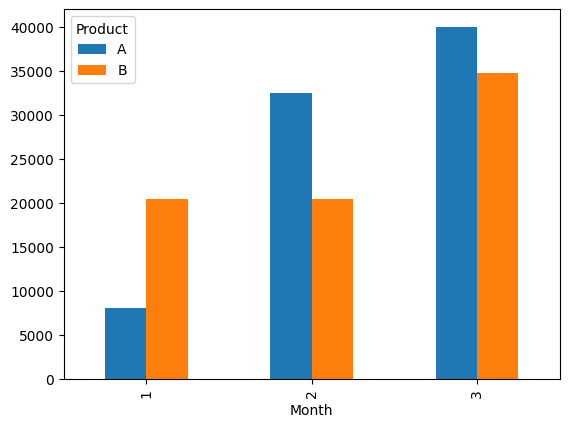

In [9]:
df_sale_pivot.plot.bar()

In [10]:
df_num_pivot = df_sale.pivot_table(
    values="Num",
    index="Month",
    columns="Product",
    aggfunc="sum"
)
df_num_pivot

Product,A,B
Month,,
1,8.0,17.0
2,32.5,17.0
3,40.0,29.0


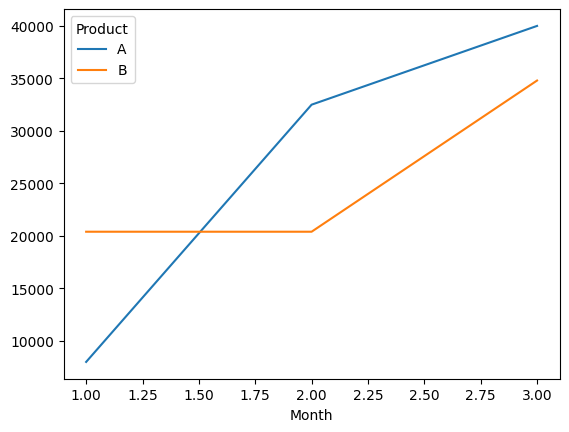

In [11]:
df_sale_pivot.plot();

In [12]:
df_sale_pivot.T

Month,1,2,3
Product,,,
A,8000.0,32500.0,40000.0
B,20400.0,20400.0,34800.0
